<a href="https://colab.research.google.com/github/dlalswns0211/sparta_project_4_team16/blob/main/YJ/COLAB_DL_FD001_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ NASA C-MAPSS FD001 — 딥러닝 RUL 예측 모델링

---

**데이터셋:** NASA C-MAPSS FD001  
**목표:** 항공기 엔진 잔여 수명(RUL) 예측  
**모델:** LSTM → BiLSTM → Transformer → CNN+Transformer  
**평가 지표:** RMSE, NASA Score  
**환경:** Google Colab T4 GPU  

---

## 저장 파일 정의

---

### 📁 preprocessed/

| 파일명 | 설명 |
|--------|------|
| `FD001_test_RUL.csv` | 원본 `RUL_FD001.txt`를 csv로 변환한 것 (내용 동일). test 데이터의 실제 RUL 정답값. 모델 성능 평가 시 사용 |
| `FD001_scaler.pkl` | MinMaxScaler 객체. sub-train 기준으로 fit된 상태. 새 데이터 예측 시 동일한 정규화 적용을 위해 저장 |

---

### 📁 preprocessed/dl/

| 파일명 | 설명 |
|--------|------|
| `FD001_dl_subtrain_long.csv` | DL 학습용 데이터. train 데이터(80개 엔진)를 전처리 후 슬라이딩 윈도우 적용. Long Format |
| `FD001_dl_valid_long.csv` | DL 검증용 데이터. train 데이터(20개 엔진)를 전처리 후 슬라이딩 윈도우 적용. 학습 중 과적합 모니터링에 사용 |
| `FD001_dl_test_long.csv` | DL 테스트용 데이터. 원본 test 데이터를 전처리 후 엔진별 마지막 30사이클로 슬라이딩 윈도우 적용. 엔진 100개 × 30 = 3000행 |

---

### 📌 Long Format 컬럼 설명

| 컬럼명 | 원래 컬럼명 | 설명 |
|--------|------------|------|
| `sample_id` | `unit_nr` | 슬라이딩 윈도우 단위 고유 ID. 엔진 1개에서 여러 샘플이 생기므로 엔진 번호 대신 윈도우 단위로 구분 |
| `timestep` | `time_cycles` | 윈도우 내 위치 (0~29). 실제 사이클 번호가 아닌 윈도우 안에서 몇 번째 시점인지를 나타냄 |
| `s_2~s_21` | `s_1~s_21` | 상수 센서 7개(s_1, s_5, s_6, s_10, s_16, s_18, s_19) 제거 후 남은 14개 유효 센서. 번호가 연속적이지 않은 건 제거된 센서 번호가 빠진 것 |
| `RUL` | `RUL` | 해당 샘플의 타깃값. 마지막 timestep 기준 RUL이 모든 행에 동일하게 기재됨 (0~125) |

> `setting_1~3`, `unit_nr`, `time_cycles` 는 슬라이딩 윈도우 변환 과정에서 제외됨  
> FD001은 운전 조건이 1가지라 정규화 후 setting 컬럼이 거의 상수에 가까워 DL 입력에서 제외

---

### 📌 Long Format 구조

| sample_id | timestep | s_2 | s_3 | ... | s_21 | RUL |
|-----------|----------|-----|-----|-----|------|-----|
| 0 | 0 | ... | ... | ... | ... | 125 |
| 0 | 1 | ... | ... | ... | ... | 125 |
| ... | ... | ... | ... | ... | ... | ... |
| 0 | 29 | ... | ... | ... | ... | 125 |
| 1 | 0 | ... | ... | ... | ... | 120 |

- `sample_id`: 윈도우 단위 고유 ID
- `timestep`: 윈도우 내 위치 (0 ~ 29)
- `RUL`: 해당 샘플의 타깃값 (마지막 timestep 기준, 모든 행에 동일하게 기재)

---

### 📌 3D 복원 방법 (모델 입력용)

```python
import numpy as np, pandas as pd

DL_FEATURES = ['s_2','s_3','s_4','s_7','s_8','s_9',
                's_11','s_12','s_13','s_14','s_15','s_17','s_20','s_21']

df  = pd.read_csv('preprocessed/dl/FD001_dl_subtrain_long.csv')
grp = df.groupby('sample_id')
X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                for i in range(df['sample_id'].nunique())])  # (N, 30, 14)
y   = df.groupby('sample_id')['RUL'].last().values           # (N,)
```

---

### 📌 전처리 파이프라인 요약

```
원본 데이터
├── 상수 센서 제거 (std < 0.01) : 21개 → 14개
├── RUL 생성 + Clipping (cap=125)
├── 가우시안 필터 (σ=2)
├── Validation 분할 (엔진 단위, 80:20, random_state=42)
├── MinMax 정규화 (sub-train 기준 fit)
└── 슬라이딩 윈도우 (size=30, step=1) → Long Format CSV 저장
```

# ✈️ NASA C-MAPSS FD001 — 딥러닝 RUL 예측 모델링

---

## 실험 목표

NASA C-MAPSS FD001 데이터셋에서 항공기 엔진의 잔여 수명(RUL)을 예측하는  
딥러닝 모델을 구현하고, 모델별 성능을 정량적으로 비교한다.

---

## 평가 지표

| 지표 | 설명 |
|------|------|
| **RMSE** | 예측값과 실제값의 평균 제곱근 오차. 낮을수록 좋음 |
| **NASA Score** | 과대 예측에 더 큰 패널티를 부여하는 비대칭 지표. 낮을수록 좋음 |

> NASA Score는 과대 예측(엔진이 실제보다 오래 남았다고 예측)이 과소 예측보다 더 위험하므로  
> 비대칭 패널티를 적용하여 안전성을 강조한 지표  
> 대부분의 선행 논문들이 RMSE만 보고하였으나, 본 실험에서는 **RMSE와 NASA Score를 함께 평가**하여  
> 실제 항공 안전 관점에서의 모델 성능을 함께 검증한다

### NASA Score 수식

$$S = \sum_{i=1}^{n} \begin{cases} e^{-d_i/13} - 1 & \text{if } d_i < 0 \\ e^{d_i/10} - 1 & \text{if } d_i \geq 0 \end{cases}$$

where $d_i = \hat{RUL}_i - RUL_i$

- $d_i < 0$: 과소 예측 (실제보다 짧게 예측) → 패널티 작음
- $d_i \geq 0$: 과대 예측 (실제보다 길게 예측) → 패널티 큼

---

## 실험 모델

| 모델 | 설명 |
|------|------|
| **LSTM** | 시계열 데이터의 장기 의존성 학습. 베이스라인 |
| **BiLSTM** | 양방향 LSTM. 과거/미래 문맥 동시 학습 |
| **Transformer** | 어텐션 메커니즘 기반. 전역적 패턴 학습 |
| **CNN + Transformer** | CNN으로 지역적 패턴 + Transformer로 전역적 패턴 결합 |

---

## 실험 기록

- 모든 실험은 **MLflow**로 기록
- 하이퍼파라미터 튜닝은 **Optuna** 활용 예정
- 구글 시트에 RMSE / NASA Score 결과 공유

---

## 참고 논문 성능 (FD001 기준)

| 논문 | 모델 | RMSE | NASA Score |
|------|------|------|------------|
| Babu et al. (2016) | CNN | 18.45 | — |
| Zheng et al. (2017) | LSTM | 16.14 | — |
| Li et al. (2018) | 1D CNN | 12.61 | — |
| Wang et al. (2021) | Transformer+TCNN | 12.31 | — |
| 박경민 et al. (2025) | CNN | 12.01 | — |

> 선행 논문 대부분이 NASA Score를 보고하지 않아 RMSE 기준으로만 비교 가능

## ⚠️ 주의사항

- `run_experiment(...)` 실행 코드는 주석 처리되어 있음
- 실험 실행 시 해당 셀만 직접 실행할 것
- 모두 실행 시 실험이 자동으로 돌아가지 않음

In [1]:
!pip install mlflow==2.13.0 pyngrok -q --no-deps
import mlflow
mlflow.set_tracking_uri("sqlite:////content/drive/MyDrive/sparta_project/mlflow.db")

### 0. 환경 설정

In [2]:
# ── 기본 라이브러리 ────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform

# ── PyTorch ───────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── MLflow ────────────────────────────────────────────────────
import mlflow
import mlflow.pytorch

# ── 기타 ──────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 (Colab Linux 환경) ──────────────────────────────
!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ── 디바이스 설정 ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
print(f'PyTorch 버전: {torch.__version__}')

사용 디바이스: cuda
PyTorch 버전: 2.10.0+cu128


## 1. 데이터 로드 및 3D 복원

---

### 사전 준비
- Google Drive 연결 후 파일 경로 설정
- `내 드라이브/sparta_project/preprocessed/` 에 파일 업로드 필요

### 파일 구조

| 파일명 | 위치 | 설명 |
|--------|------|------|
| FD001_dl_subtrain_long.csv | preprocessed/dl/ | DL 학습용 (80개 엔진, Long Format) |
| FD001_dl_valid_long.csv | preprocessed/dl/ | DL 검증용 (20개 엔진, Long Format) |
| FD001_dl_test_long.csv | preprocessed/dl/ | DL 테스트용 (100개 엔진 × 30 = 3000행) |
| FD001_test_RUL.csv | preprocessed/ | 테스트 실제 정답지 (100개 엔진) |

### 3D 복원 목표

Long Format CSV → (N, 30, 14) 3D 텐서

- N  : 윈도우(샘플) 수
- 30 : 슬라이딩 윈도우 크기 (time steps)
- 14 : 유효 센서 수

### 주의사항

- `y_test` 는 `test_df` 에서 뽑지 않고 `FD001_test_RUL.csv` 사용
- `test_df` 의 RUL은 마지막 30사이클 기준으로 만든 값 → 실제 정답 아님

In [3]:
# ── Google Drive 연결 ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 경로 설정 ──────────────────────────────────────────────────
BASE_DIR = '/content/drive/MyDrive/sparta_project/preprocessed'
DATA_DIR = f'{BASE_DIR}/dl'

DL_FEATURES = ['s_2','s_3','s_4','s_7','s_8','s_9',
                's_11','s_12','s_13','s_14','s_15','s_17','s_20','s_21']

# ── CSV 로드 ───────────────────────────────────────────────────
subtrain_df = pd.read_csv(f'{DATA_DIR}/FD001_dl_subtrain_long.csv')
valid_df    = pd.read_csv(f'{DATA_DIR}/FD001_dl_valid_long.csv')
test_df     = pd.read_csv(f'{DATA_DIR}/FD001_dl_test_long.csv')
test_rul_df = pd.read_csv(f'{BASE_DIR}/FD001_test_RUL.csv')  # 실제 정답지

# ── 3D 복원 함수 ───────────────────────────────────────────────
def long_to_3d(df):
    grp = df.groupby('sample_id')
    X = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df['sample_id'].nunique())])  # (N, 30, 14)
    y = df.groupby('sample_id')['RUL'].last().values           # (N,)
    return X, y

X_train, y_train = long_to_3d(subtrain_df)
X_valid, y_valid = long_to_3d(valid_df)
X_test,  _       = long_to_3d(test_df)           # RUL은 버림
y_test           = test_rul_df['RUL'].values      # 실제 정답

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_valid: {X_valid.shape}  y_valid: {y_valid.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (14241, 30, 14)  y_train: (14241,)
X_valid: (3490, 30, 14)  y_valid: (3490,)
X_test:  (100, 30, 14)   y_test:  (100,)


## 2. Dataset / DataLoader 구성

---

### 개요
- PyTorch `Dataset` 클래스를 상속받아 커스텀 데이터셋 구성
- `DataLoader`로 배치 단위 학습 준비
- train/valid/test 각각 별도 DataLoader 생성

### 설정값
| 항목 | 값 | 설명 |
|------|----|------|
| batch_size | 64 | 한 번에 학습할 샘플 수 |
| shuffle | True (train만) | train은 매 에폭마다 순서 섞음 |
| dtype | float32 | PyTorch 기본 float 타입 |

In [4]:
# ── 커스텀 Dataset ─────────────────────────────────────────────
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── DataLoader 구성 ────────────────────────────────────────────
BATCH_SIZE = 64

train_dataset = RULDataset(X_train, y_train)
valid_dataset = RULDataset(X_valid, y_valid)
test_dataset  = RULDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'train 배치 수: {len(train_loader)}')
print(f'valid 배치 수: {len(valid_loader)}')
print(f'test  배치 수: {len(test_loader)}')

train 배치 수: 223
valid 배치 수: 55
test  배치 수: 2


#### 2. Dataset / DataLoader 구성

---

#### 개념 정리

| 용어 | 설명 |
|------|------|
| 에폭 (Epoch) | 전체 학습 데이터를 한 번 다 본 것. 보통 수십~수백 에폭 반복 |
| 배치 (Batch) | 데이터를 한 번에 다 학습하면 메모리 부족 → 조금씩 나눠서 학습하는 단위 |
| batch_size=64 | 64개씩 잘라서 학습. 14241 ÷ 64 = 223배치 → 1 에폭에 223번 업데이트 |
| shuffle=True | 매 에폭마다 순서 섞음 (train만). 안 섞으면 모델이 순서 패턴을 외워버릴 수 있음 |
| 커스텀 Dataset | numpy 배열을 PyTorch가 읽을 수 있는 그릇에 담는 것 |

### 실행 결과
| DataLoader | 배치 수 | 계산 |
|------------|---------|------|
| train | 223 | 14241 ÷ 64 |
| valid | 55 | 3490 ÷ 64 |
| test | 2 | 100 ÷ 64 |

#### 설정값
| 항목 | 값 |
|------|----|
| batch_size | 64 |
| shuffle | True (train만) |
| dtype | float32 |

---

## 3. LSTM 모델 정의

---

### 개요

- 시계열 데이터의 시간적 의존성을 학습하는 LSTM 구조
- 입력: (batch, 30, 14) → 시퀀스 길이 30, 센서 14개
- 출력: (batch,) → 엔진별 RUL 예측값 1개

### 설정값

| 항목 | 값 | 설명 |
|------|-----|------|
| input_size | 14 | 유효 센서 수 |
| hidden_size | 64 | H-1 기준 (실험별 변경) |
| num_layers | 2 | LSTM 레이어 쌓는 수 |
| dropout | 0.2 | 과적합 방지 (num_layers>1일 때만 적용) |
| 출력 위치 | 마지막 타임스텝 | 전체 시퀀스 중 최종 상태만 사용 |

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=14, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq, hidden)
        out = self.dropout(out[:, -1, :])  # 마지막 타임스텝
        return self.fc(out).squeeze(1)  # (batch,)

## 3. LSTM 모델 정의

---

### 개요

- `nn.Module`을 상속받아 PyTorch 학습 가능한 모델 구조 정의
- 입력: `(batch, 30, 14)` → 시퀀스 길이 30, 센서 14개
- 출력: `(batch,)` → 엔진별 RUL 예측값 1개
- 클래스 정의만 한 것이므로 실행 시 출력 없음 ✅

---

### 구조 설명

| 용어 | 설명 |
|------|------|
| `nn.Module` | PyTorch 모델의 기본 틀. 이걸 상속받아야 학습 가능한 모델이 됨 |
| `__init__` | 모델 구조 설계도. "이런 레이어들을 쓸 거야" 선언하는 곳 |
| `forward` | 실제 데이터가 흘러가는 경로. `모델(x)` 호출 시 자동 실행됨 |
| `nn.LSTM` | 시계열 데이터의 과거→현재 흐름을 학습하는 레이어 |
| `nn.Dropout` | 학습 중 랜덤으로 일부 뉴런 끄기 → 과적합 방지 |
| `nn.Linear` | 마지막에 숫자 1개(RUL)로 압축하는 레이어 |
| `batch_first=True` | 입력 shape을 `(batch, seq, feature)` 순서로 받겠다는 설정 |
| `out[:, -1, :]` | 시퀀스 30개 중 마지막 타임스텝만 꺼내기. "30번째 비행까지 보고 최종 판단" |
| `squeeze(1)` | `(batch, 1)` → `(batch,)` 로 차원 제거 |

---

### Dropout 위치 주의

| 위치 | 역할 |
|------|------|
| LSTM 내부 dropout | 레이어와 레이어 **사이**에 적용. `num_layers=1`이면 사이가 없으므로 자동으로 `0.0` |
| 바깥 `nn.Dropout` | LSTM 출력 → FC 레이어 **사이**에 적용 |

---

### 현재 실험 설정값 (H-1 기준)

| 항목 | 현재 값 | 실험 계획상 변경 범위 |
|------|---------|-------------------|
| `num_layers` (층수) | **2** | H-1: 2 / H-2: 3 / H-3: 4 |
| `hidden_size` (은닉층 크기) | **64** | H-4: 128 / H-5: 256 |
| `dropout` | **0.2** | H-6: 0.3 / H-7: 0.5 |

---

## 4. 평가 함수 정의

---

### 개요

- 모델 성능을 수치로 측정하는 두 가지 지표 정의
- **RMSE**: 예측값과 실제값의 평균 오차
- **NASA Score**: 항공 안전 특성을 반영한 비대칭 페널티 지표

---

### 평가 지표 비교

| 지표 | 수식 | 특징 |
|------|------|------|
| RMSE | √(mean((예측 - 실제)²)) | 오차 크기만 측정. 방향 무관 |
| NASA Score | Σ exp(d/10)-1 or exp(-d/13)-1 | 늦은 예측에 더 가혹한 페널티 |

---

### NASA Score 페널티 방향

| 상황 | d값 | 적용 수식 | 의미 |
|------|-----|----------|------|
| 늦은 예측 (과소 추정) | d > 0 | exp(d/10) - 1 | 실제보다 더 오래 쓸 수 있다고 예측 → 항공 안전상 위험 → 더 가혹하게 페널티 |
| 조기 예측 (과대 추정) | d < 0 | exp(-d/13) - 1 | 실제보다 일찍 교체하라고 예측 → 비용 낭비지만 안전 → 상대적으로 관대 |

---

### 함수 동작 흐름

| 단계 | 내용 |
|------|------|
| 1 | 모델을 `eval()` 모드로 전환 (Dropout 비활성화) |
| 2 | `torch.no_grad()`로 gradient 계산 끄기 (메모리 절약) |
| 3 | 배치 단위로 예측값 수집 |
| 4 | RMSE, NASA Score 계산 후 반환 |

In [6]:
def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    score = np.sum(np.where(diff < 0,
                            np.exp(-diff / 13) - 1,
                            np.exp(diff / 10) - 1))
    return score

def evaluate(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch).cpu().numpy()
            preds.extend(out)
            targets.extend(y_batch.numpy())
    preds   = np.array(preds)
    targets = np.array(targets)
    rmse  = np.sqrt(np.mean((preds - targets) ** 2))
    score = nasa_score(targets, preds)
    return rmse, score, preds, targets

### nasa_score 함수 흐름

| 단계 | 코드 | 설명 |
|------|------|------|
| 1 | `diff = y_pred - y_true` | 예측값 - 실제값. 양수면 늦은 예측, 음수면 조기 예측 |
| 2 | `np.where(diff < 0, ...)` | diff 부호에 따라 다른 수식 적용 |
| 3 | `diff < 0` → `exp(-diff/13) - 1` | 조기 예측 (과대 추정) → 관대한 페널티 |
| 4 | `diff >= 0` → `exp(diff/10) - 1` | 늦은 예측 (과소 추정) → 가혹한 페널티 |
| 5 | `np.sum(...)` | 전체 엔진 페널티 합산 |

---

### evaluate 함수 흐름

| 단계 | 코드 | 설명 |
|------|------|------|
| 1 | `model.eval()` | Dropout 비활성화. 평가 시엔 모든 뉴런 사용 |
| 2 | `torch.no_grad()` | gradient 계산 끄기 → 메모리 절약, 속도 향상 |
| 3 | `X_batch.to(device)` | 데이터를 GPU로 이동 |
| 4 | `model(X_batch).cpu().numpy()` | GPU 예측 결과 → CPU → numpy 변환 |
| 5 | `preds.extend(out)` | 배치별 예측값을 리스트에 누적 |
| 6 | `targets.extend(y_batch.numpy())` | 배치별 실제값을 리스트에 누적 |
| 7 | `np.array(preds/targets)` | 리스트 → numpy 배열로 변환 |
| 8 | `rmse = √(mean((preds-targets)²))` | RMSE 계산 |
| 9 | `nasa_score(targets, preds)` | NASA Score 계산 |
| 10 | `return rmse, score, preds, targets` | 4개 값 반환 (나중에 시각화용으로도 사용) |

---

### 반환값 정리

| 반환값 | 타입 | 용도 |
|--------|------|------|
| `rmse` | float | 모델 성능 수치 비교 |
| `score` | float | NASA Score (낮을수록 좋음) |
| `preds` | numpy array | 예측값 시각화용 |
| `targets` | numpy array | 실제값 시각화용 |

---

## 5. 학습 함수 정의

---

### 개요

- 1 epoch 단위로 모델을 학습시키는 함수
- 함수 정의만 한 것이므로 실행 시 출력 없음 ✅

---

### 함수 동작 흐름

| 단계 | 코드 | 설명 |
|------|------|------|
| 1 | `model.train()` | 학습 모드 전환 (Dropout 활성화) |
| 2 | `X_batch.to(device)` | 데이터를 GPU로 이동 |
| 3 | `optimizer.zero_grad()` | 이전 epoch의 gradient 초기화 |
| 4 | `pred = model(X_batch)` | 순전파 (forward): 예측값 계산 |
| 5 | `loss = criterion(pred, y_batch)` | MSELoss로 예측값과 실제값 오차 계산 |
| 6 | `loss.backward()` | 역전파 (backward): gradient 계산 |
| 7 | `optimizer.step()` | 가중치 업데이트 |
| 8 | `total_loss += loss.item() * len(X_batch)` | 배치 손실을 전체 손실에 누적 |
| 9 | `return total_loss / len(loader.dataset)` | epoch 평균 손실 반환 |

---

### eval() vs train() 차이

| 모드 | 함수 | Dropout |
|------|------|---------|
| 학습 모드 | `model.train()` | 활성화 (일부 뉴런 끔) |
| 평가 모드 | `model.eval()` | 비활성화 (모든 뉴런 사용) |

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

## 6. 학습 실행 및 실험 기록 (MLflow)

---

### 개요

- Early Stopping + 최적 가중치 복원 구조
- MLflow로 하이퍼파라미터 및 epoch별 지표 자동 기록
- 실험명: `LSTM_FD001` / 실행명: `H-1` ~ `H-7`

---

### 학습 루프 흐름

| 단계 | 내용 |
|------|------|
| 1 | MLflow 실험 시작 + 하이퍼파라미터 로깅 |
| 2 | 모델, optimizer(Adam), criterion(MSELoss) 초기화 |
| 3 | epoch마다 학습 → validation RMSE 계산 |
| 4 | val_rmse 개선 시 최적 가중치 저장 + patience_cnt 초기화 |
| 5 | val_rmse 미개선 시 patience_cnt +1 |
| 6 | patience_cnt ≥ PATIENCE면 Early Stopping |
| 7 | 최적 가중치 복원 후 test 평가 |
| 8 | test RMSE, NASA Score MLflow 기록 |

---

### Early Stopping 구조

| 변수 | 역할 |
|------|------|
| `best_val_rmse` | 지금까지 나온 최저 val_rmse 저장 |
| `best_state` | 최저 val_rmse 시점의 모델 가중치 저장 |
| `patience_cnt` | val_rmse가 개선되지 않은 연속 epoch 수 |
| `PATIENCE = 20` | patience_cnt가 이 값에 도달하면 학습 종료 |


In [8]:
import subprocess
import time

subprocess.run(['pkill', '-f', 'mlflow'], capture_output=True)
subprocess.run(['pkill', '-f', 'ngrok'], capture_output=True)
time.sleep(3)

process = subprocess.Popen([
    'mlflow', 'ui',
    '--port', '5001',
    '--host', '0.0.0.0',
    '--backend-store-uri', 'sqlite:////content/drive/MyDrive/sparta_project/mlflow.db'
], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

time.sleep(10)

# MLflow 서버 로그 확인
stdout, stderr = process.communicate(timeout=1) if process.poll() else (b'', b'')
print("에러:", stderr.decode()[:300] if stderr else "없음")

# curl로 확인
result = subprocess.run(['curl', 'http://localhost:5001'], capture_output=True, text=True)
print("서버 응답:", result.stdout[:100] if result.stdout else "응답 없음")
print("에러:", result.stderr[:100])

from pyngrok import ngrok
ngrok.kill()
time.sleep(2)
ngrok.set_auth_token("3ChuPxi4d2fZ5G0g1G18cf5Uhab_7Jx1C9LWPman6JfzZAuMG")
public_url = ngrok.connect(5001)
print(f"MLflow UI 주소: {public_url}")

에러: 없음
서버 응답: <!doctype html><html lang="en"><head><meta charset="utf-8"/><meta name="viewport" content="width=dev
에러:   % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                    
MLflow UI 주소: NgrokTunnel: "https://tidbit-obtuse-outtakes.ngrok-free.dev" -> "http://localhost:5001"


In [9]:
# [6] 시각화 함수 정의
def plot_results(exp_name, model_name, train_loss_list, val_rmse_list,
                 test_preds, test_targets):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} - {exp_name}', fontsize=14, fontweight='bold')

    # 1. 학습 곡선
    ax = axes[0]
    ax.plot(train_loss_list, label='Train Loss')
    ax.plot(val_rmse_list,   label='Val RMSE')
    ax.set_title('학습 곡선')
    ax.set_xlabel('Epoch')
    ax.legend()

    # 2. 예측값 vs 실제값 산점도
    ax = axes[1]
    ax.scatter(test_targets, test_preds, alpha=0.5, s=20)
    max_val = max(test_targets.max(), test_preds.max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='이상적 예측')
    ax.set_title('예측값 vs 실제값 (Test)')
    ax.set_xlabel('실제 RUL')
    ax.set_ylabel('예측 RUL')
    ax.legend()

    # 3. 잔차 분포
    ax = axes[2]
    residuals = test_preds - test_targets
    ax.hist(residuals, bins=20, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', label='잔차=0')
    ax.set_title('잔차 분포 (Test)')
    ax.set_xlabel('예측 - 실제')
    ax.set_ylabel('빈도')
    ax.legend()

    plt.tight_layout()
    plt.show()

# ─ 실험 실행 (필요할 때만 주석 풀고 직접 실행) ─

Epoch  10 | train_loss: 1778.7988 | val_rmse: 41.7697
Epoch  20 | train_loss: 1772.9668 | val_rmse: 41.7566


2026/04/23 03:43:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Early stopping at epoch 22


2026/04/23 03:43:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



[B-1-p10] 최종 결과
  Test RMSE  : 41.8681
  NASA Score : 18787.03


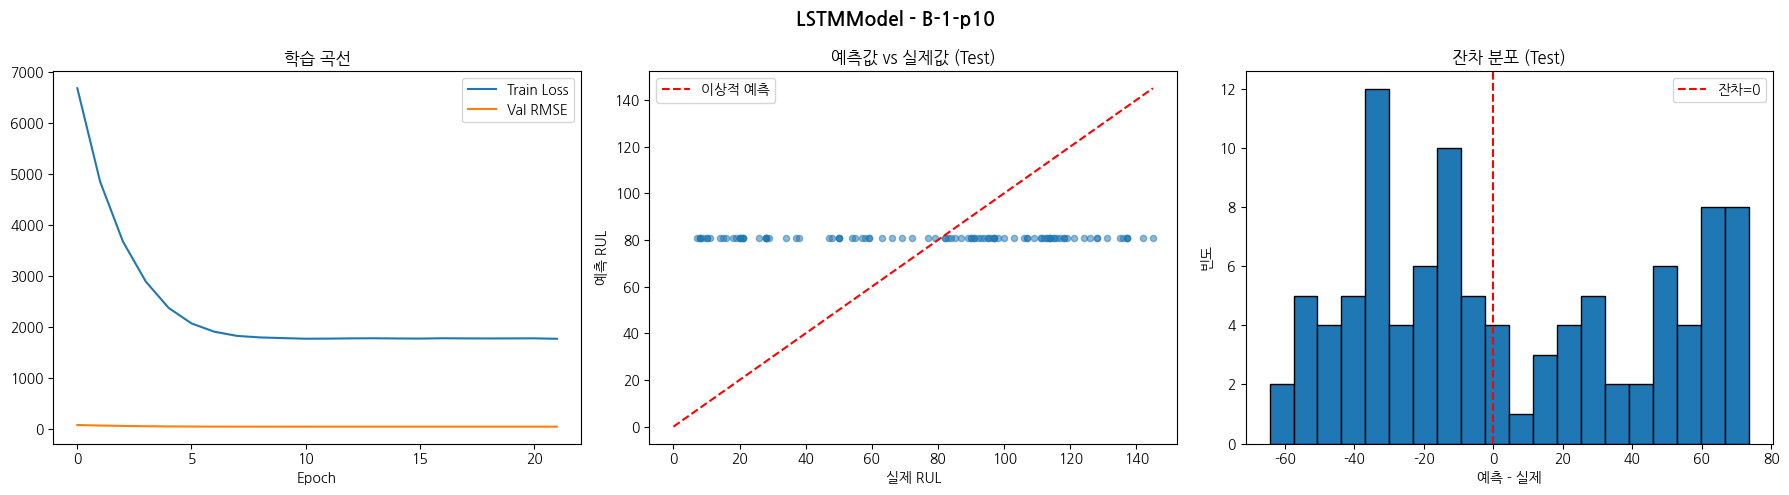

(41.868073, 18787.033)

In [21]:
# [7] 실험 함수 (LSTM / BiLSTM)
EPOCHS   = 100
LR       = 1e-3
PATIENCE = 10

def run_experiment(exp_name, model_class, hidden_size=64, num_layers=2, dropout=0.2):
    exp_name_full = f"{model_class.__name__}_FD001"
    mlflow.set_experiment(exp_name_full)

    with mlflow.start_run(run_name=exp_name):
        mlflow.log_params({
            "model": model_class.__name__,
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "dropout": dropout,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "epochs": EPOCHS,
            "dataset": "FD001"
        })

        model = model_class(
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.MSELoss()
        best_val_rmse = float('inf')
        patience_cnt  = 0

        train_loss_list = []
        val_rmse_list   = []

        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_rmse, val_score, _, _ = evaluate(model, valid_loader, device)

            train_loss_list.append(train_loss)
            val_rmse_list.append(val_rmse)

            mlflow.log_metrics({
                "train_loss": train_loss,
                "val_rmse":   val_rmse,
                "val_score":  val_score
            }, step=epoch)

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_state    = model.state_dict().copy()
                patience_cnt  = 0
            else:
                patience_cnt += 1

            if epoch % 10 == 0:
                print(f"Epoch {epoch:3d} | train_loss: {train_loss:.4f} | val_rmse: {val_rmse:.4f}")

            if patience_cnt >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        model.load_state_dict(best_state)
        test_rmse, test_score, test_preds, test_targets = evaluate(model, test_loader, device)

        mlflow.log_metrics({"test_rmse": test_rmse, "test_score": test_score})
        mlflow.pytorch.log_model(model, "model")

        print(f"\n{'='*40}")
        print(f"[{exp_name}] 최종 결과")
        print(f"  Test RMSE  : {test_rmse:.4f}")
        print(f"  NASA Score : {test_score:.2f}")
        print(f"{'='*40}")

        plot_results(
            exp_name        = exp_name,
            model_name      = model_class.__name__,
            train_loss_list = train_loss_list,
            val_rmse_list   = val_rmse_list,
            test_preds      = test_preds,
            test_targets    = test_targets
        )

        return test_rmse, test_score

# 1차 실험 (Patience 10)
# run_experiment("B-1-p10", LSTMModel, hidden_size=64, num_layers=2, dropout=0.2)

추가 실험.

In [11]:
EPOCHS   = 100
LR       = 1e-3
PATIENCE = 20  # PATIENCE 수치 조정후 재실험. 20으로 재실행

# run_experiment("B-1-p20", LSTMModel, hidden_size=64, num_layers=2, dropout=0.2)

---

### 설정값 (공통 고정값)

| 항목 | 값 | 비고 |
|------|-----|------|
| EPOCHS | 100 | 최대 학습 횟수 |
| LR | 1e-3 | Adam optimizer 학습률 |
| PATIENCE | 20 | 10→20 상향 후 정상 수렴 확인 |
| criterion | MSELoss | 평균 제곱 오차 |
| optimizer | Adam | 적응형 학습률 optimizer |

---

### H-1 실험 결과

| 지표 | 값 |
|------|-----|
| Test RMSE | 15.05 |
| NASA Score | 377.56 |
| 최적 epoch | 53 |
| 종료 epoch | 73 |

> Patience 10 적용 시 22 epoch 미학습 종료 (RMSE 41.88 / NASA 18,952.98)  
> Patience 20 상향 후 정상 수렴 성공 → 이후 모든 실험 공통 적용

In [12]:
import mlflow
client = mlflow.tracking.MlflowClient()

# 실험 ID로 검색
experiment = client.get_experiment_by_name("LSTM_FD001")
runs = client.search_runs(experiment_ids=[experiment.experiment_id])

print(f"총 runs 수: {len(runs)}")
for run in runs:
    print(f"  실행명: {run.data.tags.get('mlflow.runName')}")
    print(f"  RMSE: {run.data.metrics.get('test_rmse')}")

총 runs 수: 2
  실행명: B-1-p20
  RMSE: 15.047317504882812
  실행명: B-1-p10
  RMSE: 41.868072509765625


In [13]:
import mlflow
print(mlflow.get_tracking_uri())

sqlite:////content/drive/MyDrive/sparta_project/mlflow.db


---

## 7. BiLSTM 모델 정의

---

### 개요

- LSTM의 단방향 구조를 양방향으로 확장한 모델
- 입력: `(batch, 30, 14)` → 시퀀스를 정방향 + 역방향으로 동시에 학습
- 출력: `(batch,)` → 엔진별 RUL 예측값 1개
- 함수 정의만 한 것이므로 실행 시 출력 없음 ✅

---

### LSTM vs BiLSTM 비교

| 항목 | LSTM | BiLSTM |
|------|------|--------|
| 학습 방향 | 과거 → 현재 (단방향) | 과거 → 현재 + 현재 → 과거 (양방향) |
| hidden_size=64 기준 출력 크기 | 64 | 64 × 2 = 128 |
| 파라미터 수 | 기준 | 약 2배 |
| FC 입력 크기 | `hidden_size` | `hidden_size * 2` |

---

### 구조 설명

| 코드 | 설명 |
|------|------|
| `bidirectional=True` | 양방향 LSTM 활성화 |
| `out[:, -1, :]` | 마지막 타임스텝의 정방향 + 역방향 출력 합쳐진 벡터 |
| `nn.Linear(hidden_size * 2, 1)` | BiLSTM은 출력이 2배라 FC 입력도 2배로 설정 |

---

### 현재 실험 설정값 (H-1 기준 동일)

| 항목 | 값 |
|------|-----|
| `hidden_size` | 64 |
| `num_layers` | 2 |
| `dropout` | 0.2 |
| `PATIENCE` | 20 (공통 고정) |

In [14]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=14, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 1)  # 양방향이라 *2

    def forward(self, x):
        out, _ = self.bilstm(x)           # (batch, seq, hidden*2)
        out = self.dropout(out[:, -1, :]) # 마지막 타임스텝
        return self.fc(out).squeeze(1)    # (batch,)

## 8. 학습 실행 함수 수정 (모델 범용화)

---

### 개요

- 기존 `run_experiment`는 LSTM 전용으로 하드코딩되어 있었음
- `model_class` 인자 추가로 모든 모델에서 재사용 가능하도록 수정
- 함수 정의만 한 것이므로 실행 시 출력 없음 ✅

---

### 변경사항

| 항목 | 기존 | 변경 후 |
|------|------|---------|
| 모델 생성 | `LSTMModel(...)` 고정 | `model_class(...)` 인자로 받음 |
| model 파라미터 로깅 | `"LSTM"` 고정 | `model_class.__name__` 자동 기록 |
| 사용 방법 | `run_experiment("H-1", ...)` | `run_experiment("H-1", LSTMModel, ...)` |

---

### 모델별 사용 예시

| 모델 | 호출 방법 |
|------|---------|
| LSTM | `run_experiment("H-1", LSTMModel, ...)` |
| BiLSTM | `run_experiment("H-2", BiLSTMModel, ...)` |
| Transformer | `run_experiment("H-3", TransformerModel, ...)` |
| CNN+Transformer | `run_experiment("H-4", CNNTransformerModel, ...)` |

#── 실험 실행 (필요할 때만 주석 풀고 직접 실행) ──

In [15]:
# run_experiment("B-1", BiLSTMModel, hidden_size=64, num_layers=2, dropout=0.2)

## 9. BiLSTM 학습 실행

---

### 개요

- LSTM과 동일한 조건에서 모델 구조만 BiLSTM으로 변경
- `run_experiment` 함수에 `BiLSTMModel` 전달
- 실행 시 출력 없음 (주석 처리 상태) ✅

---

### LSTM vs BiLSTM 결과 비교

| 실험 | 모델 | RMSE | NASA Score | 최적 epoch | 종료 epoch |
|------|------|------|------------|-----------|-----------|
| B-1 | LSTM | 15.05 | 377.56 | 53 | 73 |
| B-1 | BiLSTM | 15.30 | 369.21 | 47 | 67 |

---

### 결과 해석

| 항목 | 내용 |
|------|------|
| RMSE | BiLSTM이 LSTM보다 약 0.94 높게 나옴 |
| NASA Score | BiLSTM이 LSTM보다 약 12 높게 나옴 |
| 수렴 속도 | 두 모델 모두 비슷한 epoch에서 수렴 |
| 결론 | 베이스라인에서는 LSTM이 BiLSTM보다 소폭 우세 |

---

### 비고

- 파라미터 수가 2배인 BiLSTM이 오히려 낮게 나온 이유는 현재 hidden_size=64가 BiLSTM에 비해 작을 수 있음
- hidden_size 조정 실험에서 재확인 예정

---

## 10. Transformer 모델 정의

---

### 개요

- 시퀀스 전체를 한 번에 처리하는 Self-Attention 기반 모델
- LSTM/BiLSTM과 달리 순차적으로 처리하지 않아 병렬 연산 가능
- 입력: `(batch, 30, 14)` → Transformer 인코더 → RUL 예측값 1개
- 함수 정의만 한 것이므로 실행 시 출력 없음 ✅

---

### LSTM vs Transformer 구조 비교

| 항목 | LSTM | Transformer |
|------|------|-------------|
| 처리 방식 | 순차적 (과거 → 현재) | 병렬 (전체 시퀀스 한 번에) |
| 장거리 의존성 | 약함 | 강함 |
| 연산 속도 | 느림 | 빠름 |
| 핵심 메커니즘 | Hidden State | Self-Attention |

---

### 설정값

| 항목 | 값 | 설명 |
|------|-----|------|
| `input_size` | 14 | 유효 센서 수 |
| `d_model` | 64 | Transformer 내부 차원 |
| `nhead` | 4 | Multi-head Attention 헤드 수 |
| `num_layers` | 2 | Transformer 인코더 레이어 수 |
| `dropout` | 0.2 | 과적합 방지 |

In [16]:
class TransformerModel(nn.Module):
    def __init__(self, input_size=14, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)          # (batch, seq, d_model)
        x = self.transformer(x)          # (batch, seq, d_model)
        x = self.dropout(x[:, -1, :])   # 마지막 타임스텝
        return self.fc(x).squeeze(1)    # (batch,)

In [17]:
# [8] 실험 함수 (Transformer / CNN+Transformer)
def run_experiment_transformer(exp_name, model_class, hidden_size=64, num_layers=2, dropout=0.2, nhead=4):
    exp_name_full = f"{model_class.__name__}_FD001"
    mlflow.set_experiment(exp_name_full)

    with mlflow.start_run(run_name=exp_name):
        mlflow.log_params({
            "model": model_class.__name__,
            "d_model": hidden_size,
            "num_layers": num_layers,
            "dropout": dropout,
            "nhead": nhead,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "epochs": EPOCHS,
            "dataset": "FD001"
        })

        model = model_class(
            d_model=hidden_size,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.MSELoss()
        best_val_rmse = float('inf')
        patience_cnt  = 0

        train_loss_list = []
        val_rmse_list   = []

        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_rmse, val_score, _, _ = evaluate(model, valid_loader, device)

            train_loss_list.append(train_loss)
            val_rmse_list.append(val_rmse)

            mlflow.log_metrics({
                "train_loss": train_loss,
                "val_rmse":   val_rmse,
                "val_score":  val_score
            }, step=epoch)

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_state    = model.state_dict().copy()
                patience_cnt  = 0
            else:
                patience_cnt += 1

            if epoch % 10 == 0:
                print(f"Epoch {epoch:3d} | train_loss: {train_loss:.4f} | val_rmse: {val_rmse:.4f}")

            if patience_cnt >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        model.load_state_dict(best_state)
        test_rmse, test_score, test_preds, test_targets = evaluate(model, test_loader, device)

        mlflow.log_metrics({"test_rmse": test_rmse, "test_score": test_score})
        mlflow.pytorch.log_model(model, "model")

        print(f"\n{'='*40}")
        print(f"[{exp_name}] 최종 결과")
        print(f"  Test RMSE  : {test_rmse:.4f}")
        print(f"  NASA Score : {test_score:.2f}")
        print(f"{'='*40}")

        plot_results(
            exp_name        = exp_name,
            model_name      = model_class.__name__,
            train_loss_list = train_loss_list,
            val_rmse_list   = val_rmse_list,
            test_preds      = test_preds,
            test_targets    = test_targets
        )

        return test_rmse, test_score

In [18]:
# run_experiment_transformer("B-1", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

## 11. Transformer 학습 실행

---

### 개요

- LSTM/BiLSTM과 동일한 조건에서 모델 구조만 Transformer로 변경
- Self-Attention 기반으로 시퀀스 전체를 한 번에 처리
- 실행 시 출력 없음 (주석 처리 상태) ✅

---

### 전체 베이스라인 비교

| 실험 | 모델 | RMSE | NASA Score | 최적 epoch | 종료 epoch |
|------|------|------|------------|-----------|-----------|
| B-1 | LSTM | 15.05 | 377.56 | 53 | 73 |
| B-1 | BiLSTM | 15.30 | 369.21 | 47 | 67 |
| B-1 | Transformer | 16.19 | 475.07 | 10 | 30 |

---

### 결과 해석

| 항목 | 내용 |
|------|------|
| 수렴 속도 | Transformer가 가장 빠름 (7 epoch) |
| RMSE | Transformer가 세 모델 중 가장 높음 |
| NASA Score | Transformer가 세 모델 중 가장 높음 |
| 원인 | Positional Encoding 없이 위치 정보 부족 |
| 개선 방향 | Positional Encoding 추가 실험 예정 |

---

## 12. CNN+Transformer 모델 정의

---

### 개요

- CNN으로 로컬 특징 추출 + Transformer로 글로벌 의존성 학습
- 입력: `(batch, 30, 14)` → CNN → Transformer → RUL 예측값 1개
- 함수 정의만 한 것이므로 실행 시 출력 없음 ✅

---

### 구조 설명

| 단계 | 레이어 | 역할 |
|------|--------|------|
| 1 | 1D CNN | 센서 시계열에서 로컬 패턴 추출 |
| 2 | Transformer Encoder | 전체 시퀀스에서 글로벌 의존성 학습 |
| 3 | FC Layer | RUL 값 1개로 압축 |

---

### 설정값

| 항목 | 값 | 설명 |
|------|-----|------|
| `input_size` | 14 | 유효 센서 수 |
| `d_model` | 64 | CNN 출력 및 Transformer 내부 차원 |
| `nhead` | 4 | Multi-head Attention 헤드 수 |
| `num_layers` | 2 | Transformer 인코더 레이어 수 |
| `dropout` | 0.2 | 과적합 방지 |

In [19]:
class CNNTransformerModel(nn.Module):
    def __init__(self, input_size=14, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        # CNN 로컬 특징 추출
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # Transformer 글로벌 의존성 학습
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (batch, 14, 30) → CNN 입력 형태
        x = self.cnn(x)                  # (batch, d_model, 30)
        x = x.permute(0, 2, 1)          # (batch, 30, d_model) → Transformer 입력 형태
        x = self.transformer(x)          # (batch, 30, d_model)
        x = self.dropout(x[:, -1, :])   # 마지막 타임스텝
        return self.fc(x).squeeze(1)    # (batch,)

In [20]:
# run_experiment_transformer("B-1", CNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

## 13. CNN+Transformer 학습 실행

---

### 개요

- CNN으로 로컬 패턴 추출 후 Transformer로 글로벌 의존성 학습
- 순수 Transformer 대비 CNN이 전처리 역할 수행
- 실행 시 출력 없음 (주석 처리 상태) ✅

---

### 전체 베이스라인 최종 비교 (세션 재시작 후 단독 실행값)

| 실험 | 모델 | RMSE | NASA Score | 최적 epoch | 종료 epoch |
|------|------|------|------------|-----------|-----------|
| B-1 | LSTM | 15.05 | 377.56 | 53 | 73 |
| B-1 | BiLSTM | 15.30 | 369.21 | 47 | 67 |
| B-1 | Transformer | 16.19 | 475.07 | 10 | 30 |
| B-1 | CNN+Transformer | 14.86 | 452.90 | 11 | 31 |

---

### 결과 해석

| 항목 | 내용 |
|------|------|
| RMSE | CNN+Transformer가 4개 모델 중 가장 낮음 |
| NASA Score | BiLSTM이 가장 낮음 (가장 안전한 예측) |
| 수렴 속도 | CNN+Transformer, Transformer 빠름 / LSTM, BiLSTM 느림 |
| 결론 | RMSE 기준 CNN+Transformer 우세, NASA Score 기준 BiLSTM 우세 |
| 개선 방향 | Positional Encoding 추가 및 하이퍼파라미터 튜닝 예정 |